In [ ]:
!pip install --upgrade --no-cache-dir gdown
!gdown 1SZZrpCgW8fI85m-_RpCygNuapWH3l0Vj

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2
Downloading...
From (original): https://drive.google.com/uc?id=1SZZrpCgW8fI85m-_RpCygNuapWH3l0Vj
From (redirected): https://drive.google.com/uc?id=1SZZrpCgW8fI85m-_RpCygNuapWH3l0Vj&confirm=t&uuid=29cd3843-fa60-4307-ba1f-c0ad0ce2c3d3
To: /content/archive.zip
100% 27.6M/27.6M [00:01<00:00, 20.2MB/s]


#1) Setup

In [ ]:
!pip install timm -q

In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from pathlib import Path

#2) Dataset paths

In [ ]:
!unzip -q archive.zip -d /content/dataset

In [ ]:
ROOT = Path("/content/dataset/NEU-DET")
IMG_DIR = ROOT / "IMAGES"
ANN_DIR = ROOT / "ANNOTATIONS"

print("Images:", len(list(IMG_DIR.glob("*.jpg"))))
print("Annotations:", len(list(ANN_DIR.glob("*.xml"))))

Images: 1800
Annotations: 1800


#3) XML reader

In [ ]:
def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text.strip()

    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        filename += ".jpg"

    objects = []

    for obj in root.findall("object"):
        label = obj.find("name").text.strip()
        bbox = obj.find("bndbox")

        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        objects.append({
            "label": label,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return filename, objects

#4) OpenCV preprocessing

In [ ]:
def preprocess_image(img):
    # img is grayscale

    # Contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(img)

    # Denoising / smoothing
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)

    return enhanced, blurred

#5) Segmentation with OpenCV

In [ ]:
def segment_defect(img):
    enhanced, blurred = preprocess_image(img)

    # Otsu thresholding
    _, thresh = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Morphological cleaning
    kernel = np.ones((3, 3), np.uint8)

    opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=2)

    return enhanced, blurred, thresh, closed

#6) Feature extraction

In [ ]:
def extract_contour_features(mask):
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    features = []

    for contour in contours:
        area = cv2.contourArea(contour)

        if area < 10:
            continue

        perimeter = cv2.arcLength(contour, True)

        x, y, w, h = cv2.boundingRect(contour)

        aspect_ratio = w / h if h != 0 else 0

        circularity = 0
        if perimeter > 0:
            circularity = 4 * np.pi * area / (perimeter ** 2)

        features.append({
            "area": area,
            "perimeter": perimeter,
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "aspect_ratio": aspect_ratio,
            "circularity": circularity
        })

    return features, contours

#7) Show a sample

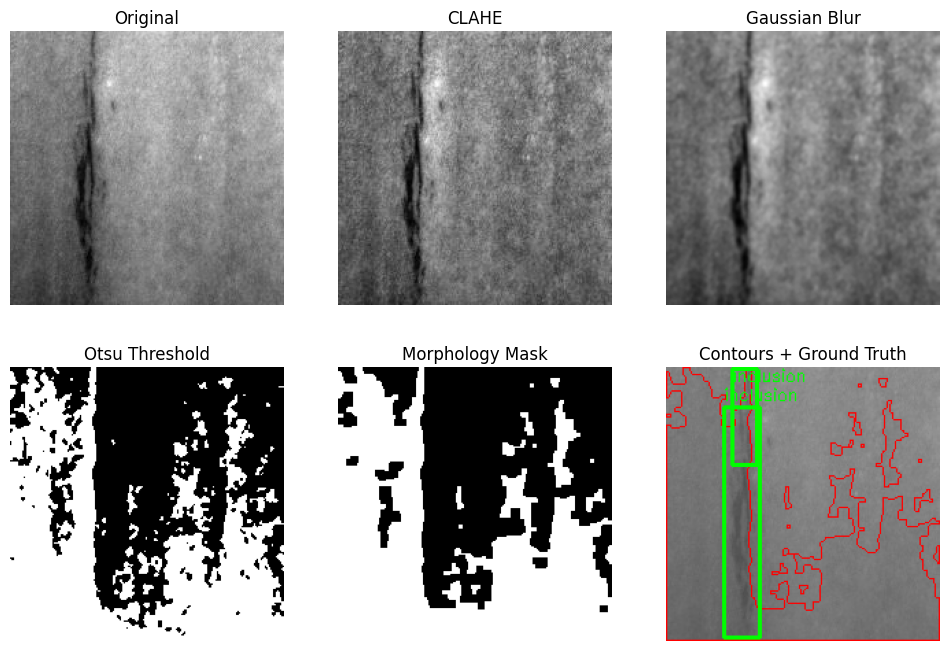

Extracted features:


,area,perimeter,x,y,w,h,aspect_ratio,circularity
0,22.5,22.242641,97,159,7,7,1.000000,0.571505
1,37.0,35.656854,77,143,12,9,1.333333,0.365700
2,32.0,30.485281,195,130,5,14,0.357143,0.432693
3,80.0,55.313708,181,89,14,17,0.823529,0.328575
4,45.5,39.071068,86,87,6,17,0.352941,0.374551


In [ ]:
xml_files = list(ANN_DIR.glob("*.xml"))
sample_xml = random.choice(xml_files)

filename, objects = parse_voc_xml(sample_xml)
img_path = IMG_DIR / filename

img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

enhanced, blurred, thresh, mask = segment_defect(img)
features, contours = extract_contour_features(mask)

vis = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

cv2.drawContours(vis, contours, -1, (255, 0, 0), 1)

for obj in objects:
    xmin, ymin, xmax, ymax = obj["bbox"]
    label = obj["label"]
    cv2.rectangle(vis, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    cv2.putText(vis, label, (xmin, max(ymin - 5, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(enhanced, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(thresh, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(mask, cmap="gray")
plt.title("Morphology Mask")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(vis)
plt.title("Contours + Ground Truth")
plt.axis("off")

plt.show()

print("Extracted features:")
pd.DataFrame(features).head()

#8) Feature extraction for the entire dataset

In [ ]:
all_features = []

for xml_path in xml_files:
    filename, objects = parse_voc_xml(xml_path)
    img_path = IMG_DIR / filename

    if not img_path.exists():
        continue

    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    enhanced, blurred, thresh, mask = segment_defect(img)
    features, contours = extract_contour_features(mask)

    true_label = objects[0]["label"] if len(objects) > 0 else "unknown"

    for feat in features:
        feat["filename"] = filename
        feat["true_label"] = true_label
        all_features.append(feat)

features_df = pd.DataFrame(all_features)

features_df.head()

,area,perimeter,x,y,w,h,aspect_ratio,circularity,filename,true_label
0,12.0,21.656854,40,136,7,7,1.000000,0.321514,rolled-in_scale_92.jpg,rolled-in_scale
1,22.5,23.071068,70,118,9,6,1.500000,0.531199,rolled-in_scale_92.jpg,rolled-in_scale
2,14.5,14.242641,59,117,5,5,1.000000,0.898249,rolled-in_scale_92.jpg,rolled-in_scale
3,2655.5,536.208151,0,91,74,109,0.678899,0.116062,rolled-in_scale_92.jpg,rolled-in_scale
4,34.5,34.242641,0,76,9,11,0.818182,0.369738,rolled-in_scale_92.jpg,rolled-in_scale


#9) Save CSV

In [ ]:
features_df.to_csv("/content/opencv_extracted_features.csv", index=False)

print("Saved:", "/content/opencv_extracted_features.csv")
print("Number of extracted regions:", len(features_df))

Saved: /content/opencv_extracted_features.csv
Number of extracted regions: 18659


In [ ]:
from google.colab import files
files.download("/content/opencv_extracted_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>